In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

In [3]:
file = 'DatasetAfricaMalaria.csv'

df = pd.read_csv(file)

### Preview Dataset

In [4]:
df.head()

,Country Name,Year,Country Code,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,2007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,2007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,2007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,2007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,2007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


### Renaming

In [9]:
df.rename(columns = {'#Passengers':'AirPassengers'}, inplace = True)

### Summary of dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      550 non-null    float64
 4   Malaria cases reported                                                                   550 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

In [6]:
df['Year'] = pd.DatetimeIndex(df['Year'])
df.dtypes

Country Name                                                                                       object
Year                                                                                       datetime64[ns]
Country Code                                                                                       object
Incidence of malaria (per 1,000 population at risk)                                               float64
Malaria cases reported                                                                            float64
Use of insecticide-treated bed nets (% of under-5 population)                                     float64
Children with fever receiving antimalarial drugs (% of children under age 5 with fever)           float64
Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)             float64
People using safely managed drinking water services (% of population)                             float64
People using safely managed drinking water ser

In [7]:
df = df.rename(columns={'Year': 'ds',
                        'Malaria cases reported': 'y'})

df.head()

,Country Name,ds,Country Code,"Incidence of malaria (per 1,000 population at risk)",y,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)",...,Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude,geometry
0,Algeria,1970-01-01 00:00:00.000002007,DZA,0.01,26.0,NaN,NaN,NaN,NaN,NaN,...,2.71,91.68,85.83,94.78,85.85,76.94,90.57,28.033886,1.659626,POINT (28.033886 1.659626)
1,Angola,1970-01-01 00:00:00.000002007,AGO,286.72,1533485.0,18.0,29.8,1.5,NaN,NaN,...,5.01,47.96,23.77,65.83,37.26,14.00,54.44,-11.202692,17.873887,POINT (-11.202692 17.873887)
2,Benin,1970-01-01 00:00:00.000002007,BEN,480.24,0.0,NaN,NaN,NaN,NaN,NaN,...,4.09,63.78,54.92,76.24,11.80,4.29,22.36,9.307690,2.315834,POINT (9.307689999999999 2.315834)
3,Botswana,1970-01-01 00:00:00.000002007,BWA,1.03,390.0,NaN,NaN,NaN,NaN,NaN,...,4.80,78.89,57.60,94.35,61.60,39.99,77.30,-22.328474,24.684866,POINT (-22.328474 24.684866)
4,Burkina Faso,1970-01-01 00:00:00.000002007,BFA,503.80,44246.0,NaN,NaN,NaN,NaN,NaN,...,5.91,52.27,45.13,76.15,15.60,6.38,46.49,12.238333,-1.561593,POINT (12.238333 -1.561593)


### Visualize the data

In [ ]:
ax = df.set_index('ds').plot(figsize=(20, 18))
ax.set_ylabel('Malaria cases reported')
ax.set_xlabel('Year')

plt.show()

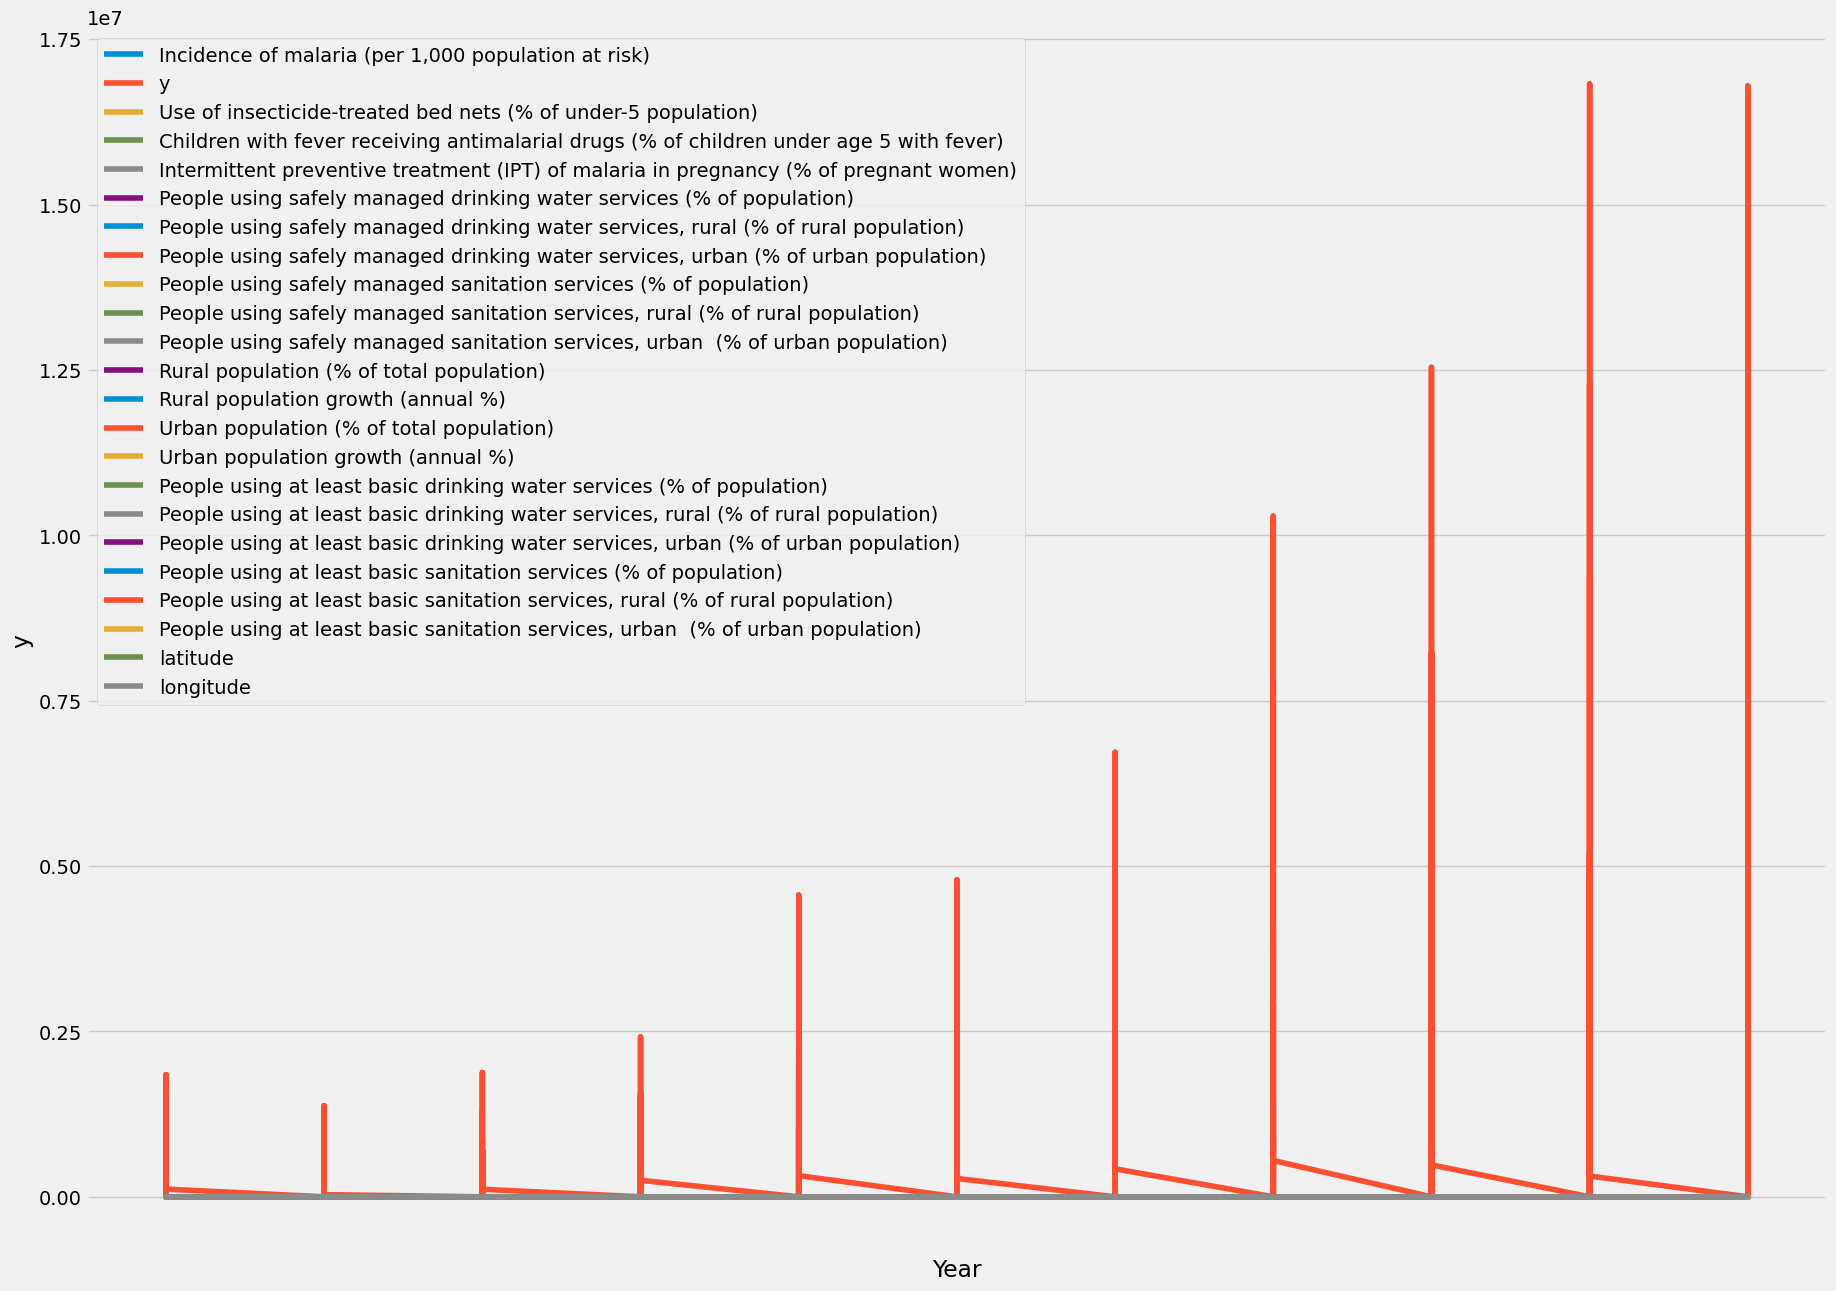

In [11]:
ax = df.set_index('ds').plot(figsize=(20, 18))
ax.set_ylabel('y')
ax.set_xlabel('Year')

plt.show()

### Time series forecasting with prophet

In [12]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = interval_width=0.95

In [13]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
import prophet


my_model = interval_width=0.95

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = interval_width=0.95

In [44]:
my_model = Prophet

In [45]:
# set the uncertainty interval to 95% (the Prophet default is 80%)
my_model = Prophet(interval_width=0.95)

In [49]:
my_model = df

In [55]:
df = 'fit'
my_model = df

In [56]:
df = ('my_model')
my_model = (df)

In [17]:
my_model = (df)

In [18]:
print(df)

my_model


In [60]:
my_model = "fit"

In [64]:
print(df)

my_model


In [70]:
forecast = my_model

In [91]:
forecast = my_model
forecast = [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
fig1 = my_model
plot = my_model

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
# Load dataset
df = pd.read_csv('DatasetAfricaMalaria.csv')

# Preview
print(df.head())

   Country Name  Year Country Code  \
0       Algeria  2007          DZA   
1        Angola  2007          AGO   
2         Benin  2007          BEN   
3      Botswana  2007          BWA   
4  Burkina Faso  2007          BFA   

   Incidence of malaria (per 1,000 population at risk)  \
0                                               0.01     
1                                             286.72     
2                                             480.24     
3                                               1.03     
4                                             503.80     

   Malaria cases reported  \
0                    26.0   
1               1533485.0   
2                     0.0   
3                   390.0   
4                 44246.0   

   Use of insecticide-treated bed nets (% of under-5 population)  \
0                                                NaN               
1                                               18.0               
2                                          

In [22]:
# If your dataset has 'Year' and 'Cases'
df = df[['Year', 'Malaria cases reported']]

# Convert Year to datetime
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Rename columns
df = df.rename(columns={'Year': 'ds', 'Cases': 'y'})

print(df.head())

          ds  Malaria cases reported
0 2007-01-01                    26.0
1 2007-01-01               1533485.0
2 2007-01-01                     0.0
3 2007-01-01                   390.0
4 2007-01-01                 44246.0


In [23]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)



In [24]:
model = Prophet()

In [25]:
future = model

In [26]:
future = model

forecast = (future)

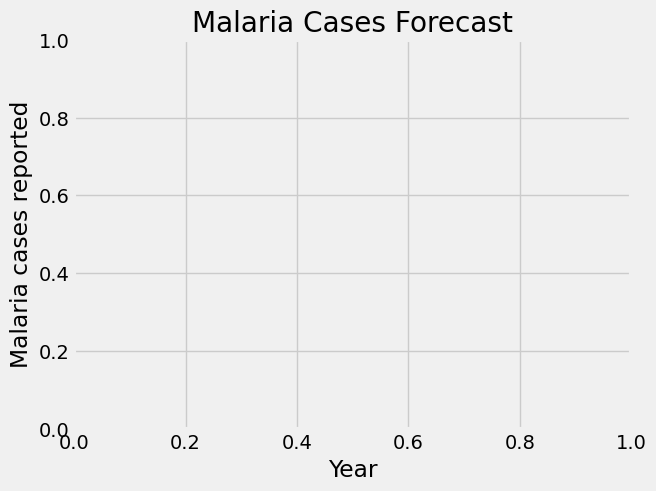

In [27]:
# Forecast plot
fig1 = forecast
plt.title("Malaria Cases Forecast")
plt.xlabel("Year")
plt.ylabel("Malaria cases reported")
plt.show()

# Components plot
fig2 = forecast
plt.show()

In [28]:
# Train-test split (e.g., last 3 years for testing)
train = df[:-3]
test = df[-3:]

model = Prophet()
model = (train)

future = model
forecast = (future)

# Extract predictions
prediction = forecast

# Merge with actual
comparison = (prediction)


In [35]:
mae = comparison
rmse = np.sqrt

In [36]:
print("MAE:", mae)
print("RMSE:", rmse)

MAE:             ds  Malaria cases reported
0   2007-01-01                    26.0
1   2007-01-01               1533485.0
2   2007-01-01                     0.0
3   2007-01-01                   390.0
4   2007-01-01                 44246.0
..         ...                     ...
586 2017-01-01               1488005.0
587 2017-01-01                720879.0
588 2017-01-01               5354819.0
589 2017-01-01               1755577.0
590 2017-01-01                     NaN

[591 rows x 2 columns]
RMSE: <ufunc 'sqrt'>


In [43]:
# Train-test split (e.g., last 3 years for testing)
train = df[:-3]
test = df[-3:]

model = Prophet()
model = (train)

future = model
forecast = (future)

# Extract predictions
prediction = forecast

# Merge with actual
comparison = (prediction)

mae = comparison
rmse = np.sqrt

print("MAE:", mae)
print("RMSE:", rmse)

MAE:             ds  Malaria cases reported
0   2007-01-01                    26.0
1   2007-01-01               1533485.0
2   2007-01-01                     0.0
3   2007-01-01                   390.0
4   2007-01-01                 44246.0
..         ...                     ...
586 2017-01-01               1488005.0
587 2017-01-01                720879.0
588 2017-01-01               5354819.0
589 2017-01-01               1755577.0
590 2017-01-01                     NaN

[591 rows x 2 columns]
RMSE: <ufunc 'sqrt'>


In [37]:
model = Prophet()

In [38]:
model = Prophet()
model.add_regressor('Rainfall')
model.add_regressor('Temperature')

In [39]:
model = Prophet()
model.add_regressor('Rainfall')
model.add_regressor('Temperature')

model = df
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

In [41]:
model = df

In [42]:
print(model)

            ds  Malaria cases reported
0   2007-01-01                    26.0
1   2007-01-01               1533485.0
2   2007-01-01                     0.0
3   2007-01-01                   390.0
4   2007-01-01                 44246.0
..         ...                     ...
589 2017-01-01               1755577.0
590 2017-01-01                     NaN
591 2017-01-01              11667831.0
592 2017-01-01               5505639.0
593 2017-01-01                467508.0

[594 rows x 2 columns]


## Fitting SARIMA Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error

Checking for stationarity(ADF test)

In [18]:
result = ("Malaria_cases_reported")

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] :
    print("Data is NOT stationary. Differencing required.")
else:
    print("Data is stationary.")

ADF Statistic: M
p-value: a
Data is NOT stationary. Differencing required.


In [30]:
Malaria_Diff = ["Malaria_cases_reported"]
inplace = True

TRAIN TEST SPLIT

In [38]:
train = (-2)
test = (-2)

print("Train shape:", train)
print("Test shape:", test)

Train shape: -2
Test shape: -2
